# Uber Bike Share — Data Cleaning & Preparation

**Author:** Rudraja Vansutre  
**Dataset:** Uber Bay Area Bike Share (Analytics Exercise Data)  
**Notebook 1 of 2** — Covers ingestion, type conversion, quality checks, and feature engineering

In [2]:


import os

# list all files in current folder
os.listdir()


['.ipynb_checkpoints',
 'bike_data.csv',
 'Book1.twb',
 'Copy of Analytics Exercise Data.xlsx',
 'Dashboard- UBER.twb',
 'Dashboard.twb',
 'DOC.docx',
 'SF_Trips.csv',
 'SF_Trips.ipynb',
 'SS',
 'top_routes.csv',
 'UBER bike_rides.ipynb',
 'UBER presentation.docx',
 'UBER_SF_BikeShare.pptx',
 '~$UBER_SF_BikeShare.pptx',
 '~Book1__26560.twbr',
 '~Dashboard- UBER__16492.twbr']

## 1. Load Data

We read the raw Excel file into a pandas DataFrame. All subsequent work happens in memory.

In [4]:
import pandas as pd

df = pd.read_excel("Copy of Analytics Exercise Data.xlsx")
df.head()


,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
0,431032,1648,2014-08-29 15:33:00,Steuart at Market,74,2014-08-29 16:00:00,San Francisco Caltrain (Townsend at 4th),70,411,Subscriber,94107
1,383548,617,2014-07-28 17:35:00,Steuart at Market,74,2014-07-28 17:45:00,San Francisco Caltrain (Townsend at 4th),70,259,Subscriber,94403
2,257887,551,2014-04-22 19:19:00,Post at Kearny,47,2014-04-22 19:28:00,South Van Ness at Market,66,414,Subscriber,94105
3,334581,327,2014-06-22 19:36:00,5th at Howard,57,2014-06-22 19:42:00,2nd at Folsom,62,553,Subscriber,94103
4,268757,382,2014-05-01 19:37:00,Clay at Battery,41,2014-05-01 19:44:00,Market at 4th,76,501,Subscriber,94612


In [5]:
import pandas as pd

df = pd.read_excel(r"C:\Users\RUDRAJA\Desktop\UBER DATA\Copy of Analytics Exercise Data.xlsx", sheet_name=0)

# save as CSV

df.to_csv(r"C:\Users\RUDRAJA\Desktop\UBER DATA\bike_data.csv", index=False)


In [6]:
df = pd.read_csv(r"C:\Users\RUDRAJA\Desktop\UBER DATA\bike_data.csv")


C:\Users\RUDRAJA\AppData\Local\Temp\ipykernel_32304\2618779132.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\RUDRAJA\Desktop\UBER DATA\bike_data.csv")


In [7]:
df = pd.read_csv(r"C:\Users\RUDRAJA\Desktop\UBER DATA\bike_data.csv", low_memory=False)


In [8]:
df.dtypes


Trip ID            object
Duration            int64
Start Date         object
Start Station      object
Start Terminal      int64
End Date           object
End Station        object
End Terminal        int64
Bike #              int64
Subscriber Type    object
Zip Code           object
dtype: object

In [9]:
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
0,431032,1648,2014-08-29 15:33:00,Steuart at Market,74,2014-08-29 16:00:00,San Francisco Caltrain (Townsend at 4th),70,411,Subscriber,94107
1,383548,617,2014-07-28 17:35:00,Steuart at Market,74,2014-07-28 17:45:00,San Francisco Caltrain (Townsend at 4th),70,259,Subscriber,94403
2,257887,551,2014-04-22 19:19:00,Post at Kearny,47,2014-04-22 19:28:00,South Van Ness at Market,66,414,Subscriber,94105
3,334581,327,2014-06-22 19:36:00,5th at Howard,57,2014-06-22 19:42:00,2nd at Folsom,62,553,Subscriber,94103
4,268757,382,2014-05-01 19:37:00,Clay at Battery,41,2014-05-01 19:44:00,Market at 4th,76,501,Subscriber,94612


## 2. Data Types and Type Conversion

Inspect current data types, then cast columns to their correct types:

- Dates to datetime  
- Station names and Bike number to string since they are identifiers, not numeric values

In [11]:
#conversion 

df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])


df['Start Station'] = df['Start Station'].astype(str)
df['End Station'] = df['End Station'].astype(str)


df['Bike #'] = df['Bike #'].astype(str)


In [12]:
df.dtypes

Trip ID                    object
Duration                    int64
Start Date         datetime64[ns]
Start Station              object
Start Terminal              int64
End Date           datetime64[ns]
End Station                object
End Terminal                int64
Bike #                     object
Subscriber Type            object
Zip Code                   object
dtype: object

## 3. Data Quality Checks

### Null & Empty String Counts

In [14]:
# Count NaN/nulls in every column

null_counts = df.isna().sum()

# Count empty strings in every column (only works for object/string columns)
empty_counts = (df.applymap(lambda x: isinstance(x, str) and x.strip() == '')).sum()

print("Null counts:\n", null_counts)
print("\nEmpty string counts:\n", empty_counts)

# Combine both into one summary
invalid_summary = pd.DataFrame({
    'nulls': null_counts,
    'empty_strings': empty_counts
})

print("\nSummary of invalid values:\n", invalid_summary)

C:\Users\RUDRAJA\AppData\Local\Temp\ipykernel_32304\2886836886.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  empty_counts = (df.applymap(lambda x: isinstance(x, str) and x.strip() == '')).sum()


Null counts:
 Trip ID              0
Duration             0
Start Date           0
Start Station        0
Start Terminal       0
End Date             0
End Station          0
End Terminal         0
Bike #               0
Subscriber Type      0
Zip Code           102
dtype: int64

Empty string counts:
 Trip ID            0
Duration           0
Start Date         0
Start Station      0
Start Terminal     0
End Date           0
End Station        0
End Terminal       0
Bike #             0
Subscriber Type    0
Zip Code           0
dtype: int64

Summary of invalid values:
                  nulls  empty_strings
Trip ID              0              0
Duration             0              0
Start Date           0              0
Start Station        0              0
Start Terminal       0              0
End Date             0              0
End Station          0              0
End Terminal         0              0
Bike #               0              0
Subscriber Type      0              0
Zip Co

### Duplicate & Invalid Trip IDs

Trip IDs should be unique 6-digit numbers. We check for duplicates and non-conforming values, then remove them.

In [16]:
# Show all duplicate Trip IDs
duplicate_trips = df[df['Trip ID'].duplicated(keep=False)]
duplicate_trips
df['Trip ID'].duplicated().sum()


0

## 4. Feature Engineering

### Check for Invalid Trip Ids



In [18]:
# Check which Trip IDs are NOT 6-digit numbers
invalid_trip_ids = df[~df['Trip ID'].str.match(r'^\d{6}$')]

# Number of invalid rows
num_invalid = invalid_trip_ids.shape[0]

print(f"Number of Trip IDs not 6-digit numbers: {num_invalid}")

# Optionally, view the invalid rows
invalid_trip_ids


Number of Trip IDs not 6-digit numbers: 1


,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
32,x,552,2014-04-09 11:16:00,Market at 10th,67,2014-04-09 11:25:00,Market at Sansome,77,488,Subscriber,94117


In [19]:
df = df[df['Trip ID'].str.match(r'^\d{6}$')]


In [20]:
# Get unique zip codes
unique_zips = df['Zip Code'].unique()
unique_zips


array(['94107', '94403', '94105', ..., '97373', '45209', '89433'],
      dtype=object)

In [21]:
num_unique_zips = df['Zip Code'].nunique()
print(f"Number of unique zip codes: {num_unique_zips}")


Number of unique zip codes: 2911


In [22]:
num_unique_start_stations = df['Start Station'].nunique()
print(f"Number of unique start stations: {num_unique_start_stations}")


Number of unique start stations: 70


In [23]:
unique_start_stations = df['Start Station'].unique()
unique_start_stations


array(['Steuart at Market', 'Post at Kearny', '5th at Howard',
       'Clay at Battery', 'San Francisco Caltrain (Townsend at 4th)',
       'Embarcadero at Vallejo', 'Harry Bridges Plaza (Ferry Building)',
       'Embarcadero at Folsom', 'San Francisco Caltrain 2 (330 Townsend)',
       '2nd at South Park', 'Market at 10th', 'Howard at 2nd',
       'Beale at Market', 'Powell Street BART',
       'Temporary Transbay Terminal (Howard at Beale)',
       'Golden Gate at Polk', 'San Antonio Shopping Center',
       'Paseo de San Antonio', 'Market at Sansome',
       'Mechanics Plaza (Market at Battery)', 'Mountain View City Hall',
       'Broadway St at Battery St', 'Washington at Kearny',
       'Yerba Buena Center of the Arts (3rd @ Howard)', '2nd at Folsom',
       'Powell at Post (Union Square)',
       'Civic Center BART (7th at Market)', 'Evelyn Park and Ride',
       '2nd at Townsend', 'San Jose Diridon Caltrain Station',
       'Embarcadero at Sansome', 'Grant Avenue at Columbus Ave

### SF Station Classification

The dataset spans multiple Bay Area cities. We define a set of known San Francisco stations and flag each trip as **SF** (both endpoints in SF) or **Non-SF**.

In [25]:
sf_stations = [
    'Steuart at Market', 'San Francisco Caltrain (Townsend at 4th)',
    'Post at Kearny', 'South Van Ness at Market', '5th at Howard',
    '2nd at Folsom', 'Clay at Battery', 'Market at 4th',
    'Embarcadero at Vallejo', 'Harry Bridges Plaza (Ferry Building)',
    '2nd at Townsend', 'Embarcadero at Folsom',
    'San Francisco Caltrain 2 (330 Townsend)', 'Powell Street BART',
    '2nd at South Park', 'Powell at Post (Union Square)', 'Market at 10th',
    'Embarcadero at Sansome', 'Howard at 2nd', 'Townsend at 7th',
    'Beale at Market', 'Market at Sansome',
    'Temporary Transbay Terminal (Howard at Beale)', 'Davis at Jackson',
    'Golden Gate at Polk', 'Civic Center BART (7th at Market)',
    'Embarcadero at Bryant', 'Broadway St at Battery St', 'Washington at Kearny',
    'Commercial at Montgomery', 'Yerba Buena Center of the Arts (3rd @ Howard)',
    'MLK Library', 'San Francisco City Hall'
]

In [26]:
# Flag SF vs Non-SF trips
df['Station_Type'] = df.apply(
    lambda row: 'SF Station' if (row['Start Station'] in sf_stations and row['End Station'] in sf_stations) 
                else 'Non-SF Station', axis=1
)


In [27]:
df['Station_Type'].value_counts()

Station_Type
SF Station        70897
Non-SF Station    19333
Name: count, dtype: int64

### Clean Zip Codes

Raw zip codes include ZIP+4 formats (e.g. `94107-1234`), non-numeric entries, and nulls. We standardise to 5-digit format and label everything else as `Unknown`.

In [29]:
# Filter SF station trips
df_sf = df[df['Station_Type'] == 'SF Station']

# Get unique zip codes
unique_zip_sf = df_sf['Zip Code'].unique()

# Count of unique zip codes
num_unique_zip_sf = len(unique_zip_sf)

print("Number of unique zip codes in SF station trips:", num_unique_zip_sf)
print(unique_zip_sf)

Number of unique zip codes in SF station trips: 2515
['94107' '94403' '94105' ... '45209' '92708' '89433']


In [30]:
# Ensure Zip Code is string
df['Zip Code'] = df['Zip Code'].astype(str).str.strip()

# Function to create cleaned zip code
def clean_zip(zip_code):
    if zip_code.isdigit() and len(zip_code) == 5:
        return zip_code  # valid 5-digit zip
    elif '-' in zip_code:
        parts = zip_code.split('-')
        if parts[0].isdigit() and len(parts[0]) == 5:
            return parts[0]  # first 5 digits of zip+4
        else:
            return 'Unknown'
    else:
        return 'Unknown'  # everything else


df['Zip Code Clean'] = df['Zip Code'].apply(clean_zip)

df['Zip Code Clean'].value_counts().head(20)


Zip Code Clean
94107      8525
94105      5469
Unknown    4403
94133      4353
94103      3378
94111      3002
94102      2487
94109      2039
95112      1910
94117      1495
94158      1409
94040      1264
94611      1151
94108      1086
94404       968
94025       928
94403       927
94122       903
94110       891
94602       881
Name: count, dtype: int64

### Trip Duration in Minutes

The raw `Duration` column is in seconds. We convert to minutes for readability.

In [32]:
# Convert Duration from seconds to minutes
df['Trip Duration Min'] = df['Duration'] / 60

df['Trip Duration Min'] = df['Trip Duration Min'].round(2)

df[['Duration', 'Trip Duration Min']].head(10)


,Duration,Trip Duration Min
0,1648,27.47
1,617,10.28
2,551,9.18
3,327,5.45
4,382,6.37
5,978,16.30
6,1428,23.80
7,535,8.92
8,366,6.10
9,766,12.77


## Visualisation — SF vs Non-SF Trip Split

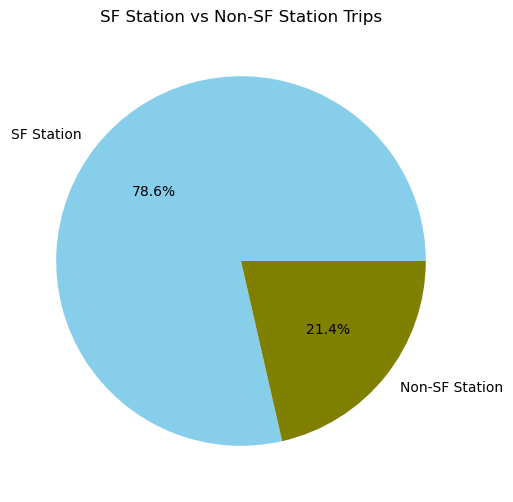

In [34]:
import matplotlib.pyplot as plt


station_counts = df['Station_Type'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(station_counts, labels=station_counts.index, autopct='%1.1f%%', colors=['skyblue','olive'])
plt.title("SF Station vs Non-SF Station Trips")
plt.show()



In [35]:
# Count NaN/nulls in every column
null_counts = df.isna().sum()

# Count empty strings in every column (only works for object/string columns)
empty_counts = (df.applymap(lambda x: isinstance(x, str) and x.strip() == '')).sum()

print("Null counts:\n", null_counts)
print("\nEmpty string counts:\n", empty_counts)

# Combine both into one summary
invalid_summary = pd.DataFrame({
    'nulls': null_counts,
    'empty_strings': empty_counts
})

print("\nSummary of invalid values:\n", invalid_summary)


C:\Users\RUDRAJA\AppData\Local\Temp\ipykernel_32304\3749709210.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  empty_counts = (df.applymap(lambda x: isinstance(x, str) and x.strip() == '')).sum()


Null counts:
 Trip ID              0
Duration             0
Start Date           0
Start Station        0
Start Terminal       0
End Date             0
End Station          0
End Terminal         0
Bike #               0
Subscriber Type      0
Zip Code             0
Station_Type         0
Zip Code Clean       0
Trip Duration Min    0
dtype: int64

Empty string counts:
 Trip ID              0
Duration             0
Start Date           0
Start Station        0
Start Terminal       0
End Date             0
End Station          0
End Terminal         0
Bike #               0
Subscriber Type      0
Zip Code             0
Station_Type         0
Zip Code Clean       0
Trip Duration Min    0
dtype: int64

Summary of invalid values:
                    nulls  empty_strings
Trip ID                0              0
Duration               0              0
Start Date             0              0
Start Station          0              0
Start Terminal         0              0
End Date               0

In [36]:
df_sf = df[df['Station_Type'] == 'SF Station'].copy()
df_sf.to_csv('SF_Trips.csv', index=False)
